<a href="https://colab.research.google.com/github/yaeliavni/AI/blob/main/LAPD_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn imbalanced-learn statsmodels seaborn holidays h3

In [2]:
from eda import run_eda

In [3]:
from supervised import quick_demo

In [4]:
from unsupervised import run_unsupervised

#Fast EDA

COMPREHENSIVE LAPD EDA PIPELINE

1. Loading raw data and applying strict cleaning...
Raw shape: (974477, 15)
STRICT dropna: removed 648,974 rows with ANY missing values
Remaining rows with complete data: 325,503
Data completeness: 33.4% of original data retained

2. Creating time-based features and target variable...
Extracting hours from column: 'Time_occured'
Sample time values: [1220, 1, 800, 1800, 1200]
Successfully extracted hours from 311723/325503 rows (95.8%)
Hour distribution:
hour
1.0     11699
2.0      9922
3.0      7631
4.0      6075
5.0      5146
6.0      5708
7.0      7758
8.0     10740
9.0     11316
10.0    13607
Name: count, dtype: int64
Night target distribution: {0: np.int64(209096), 1: np.int64(116407)}
Target balance: 35.8% minority class
Creating additional features...
Found 10 categorical columns for encoding
Final target distribution: {0: np.int64(209096), 1: np.int64(116407)}
Features with meaningful variation: 16
Top variable features: ['DR_NO', 'Time_occured',

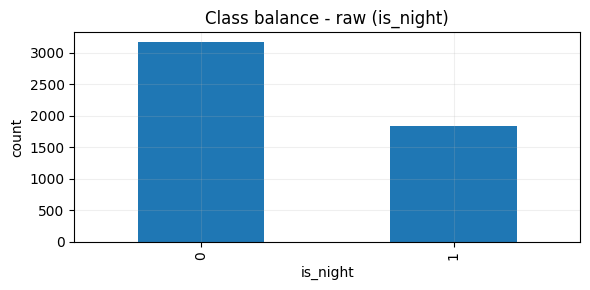

preview time plots skipped: Grouper for 'hour' not 1-dimensional
🗂️ saved: /content/figs_eda/Numeric-correlation-(Pearson)---raw.png


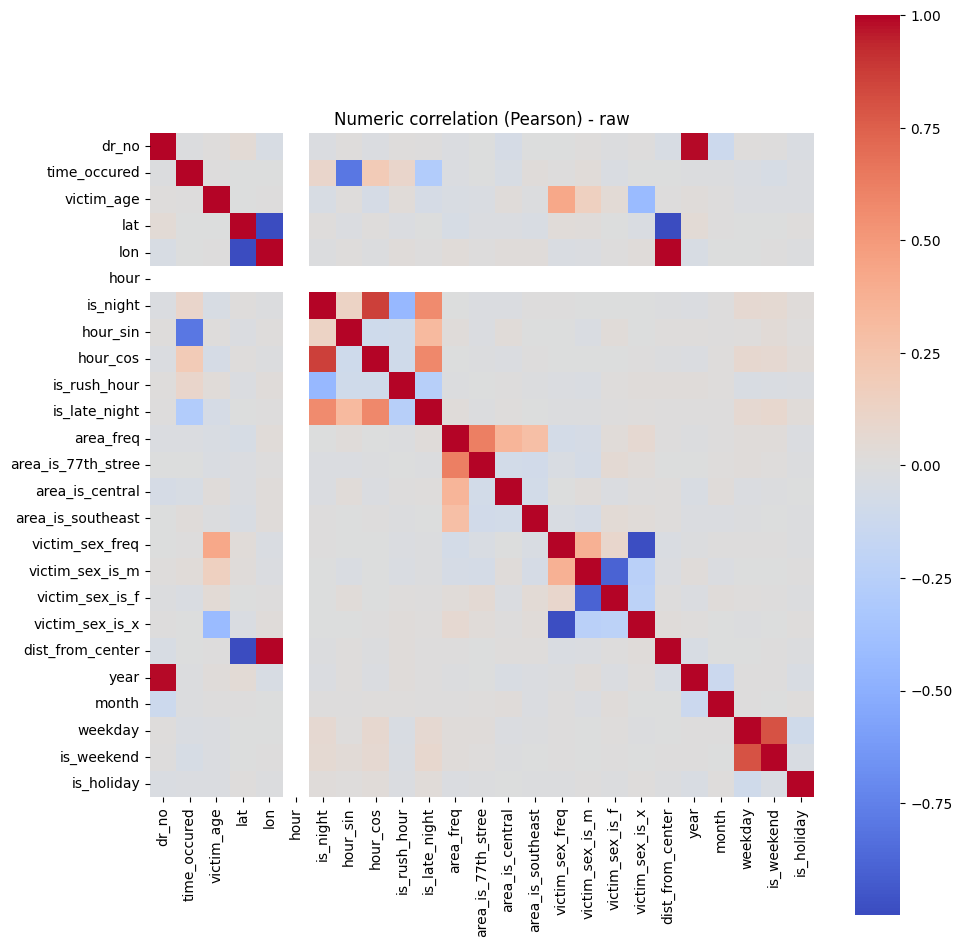

🗂️ saved: /content/figs_eda/Numeric-correlation-(Spearman)---raw.png


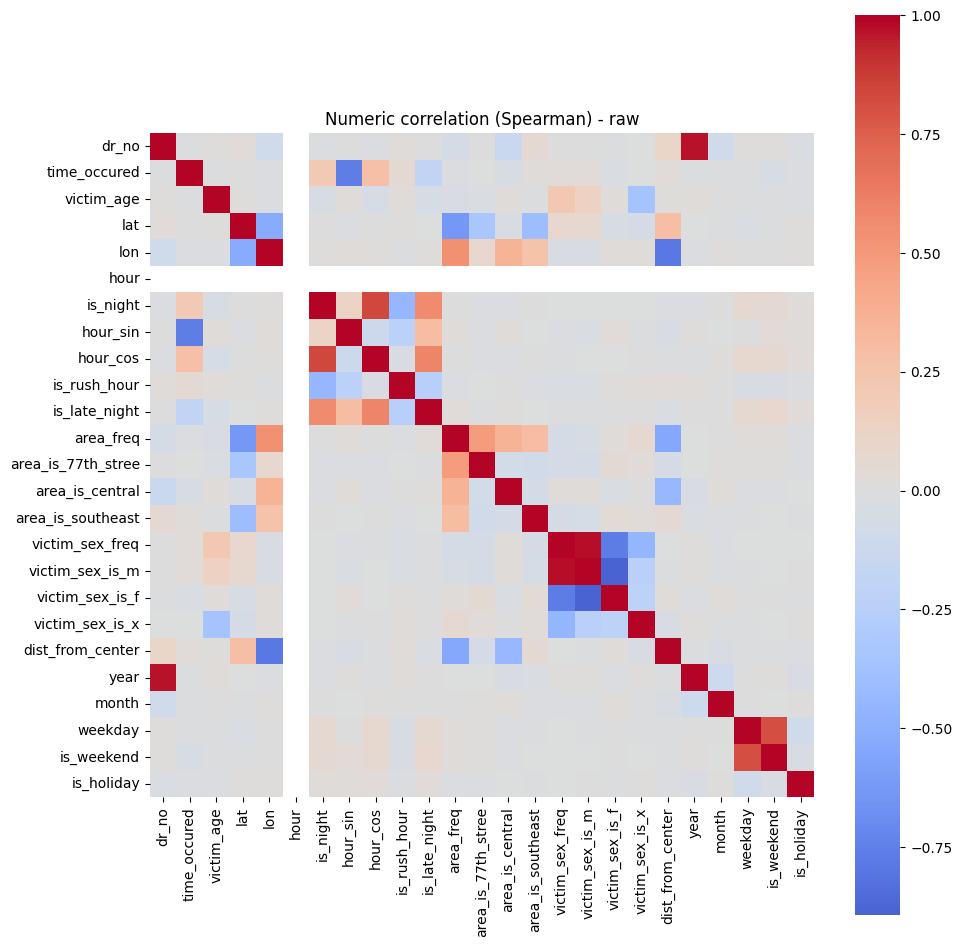

🗂️ saved: /content/figs_eda/Mixed-correlations-(num-+-cat)---raw.png


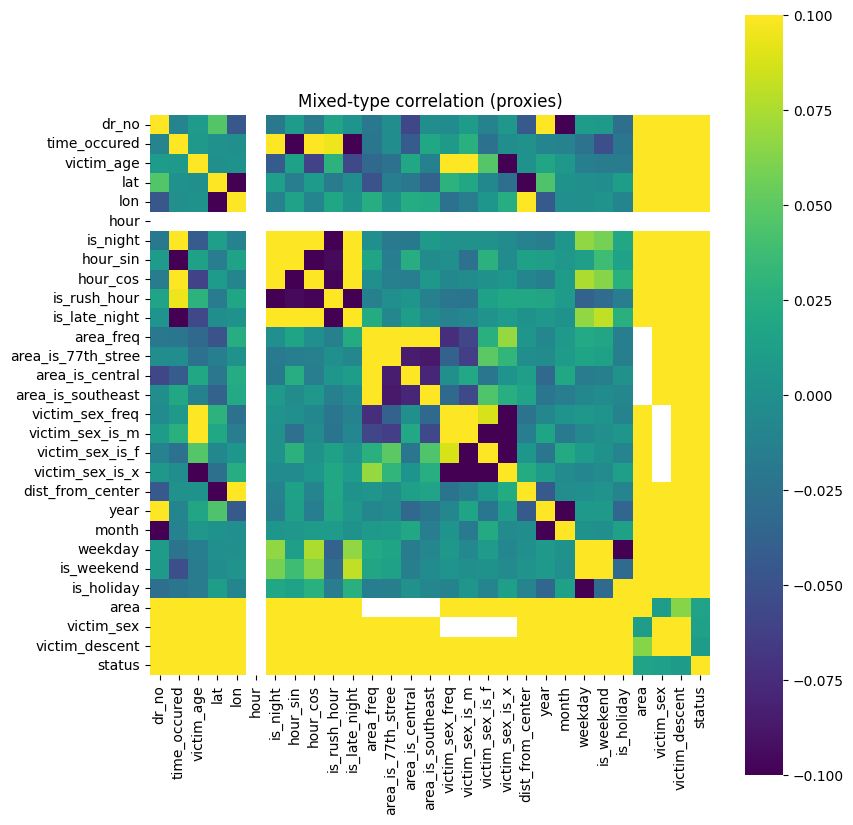

🗂️ saved: /content/figs_eda/Numeric-distributions-(hist)---raw.png


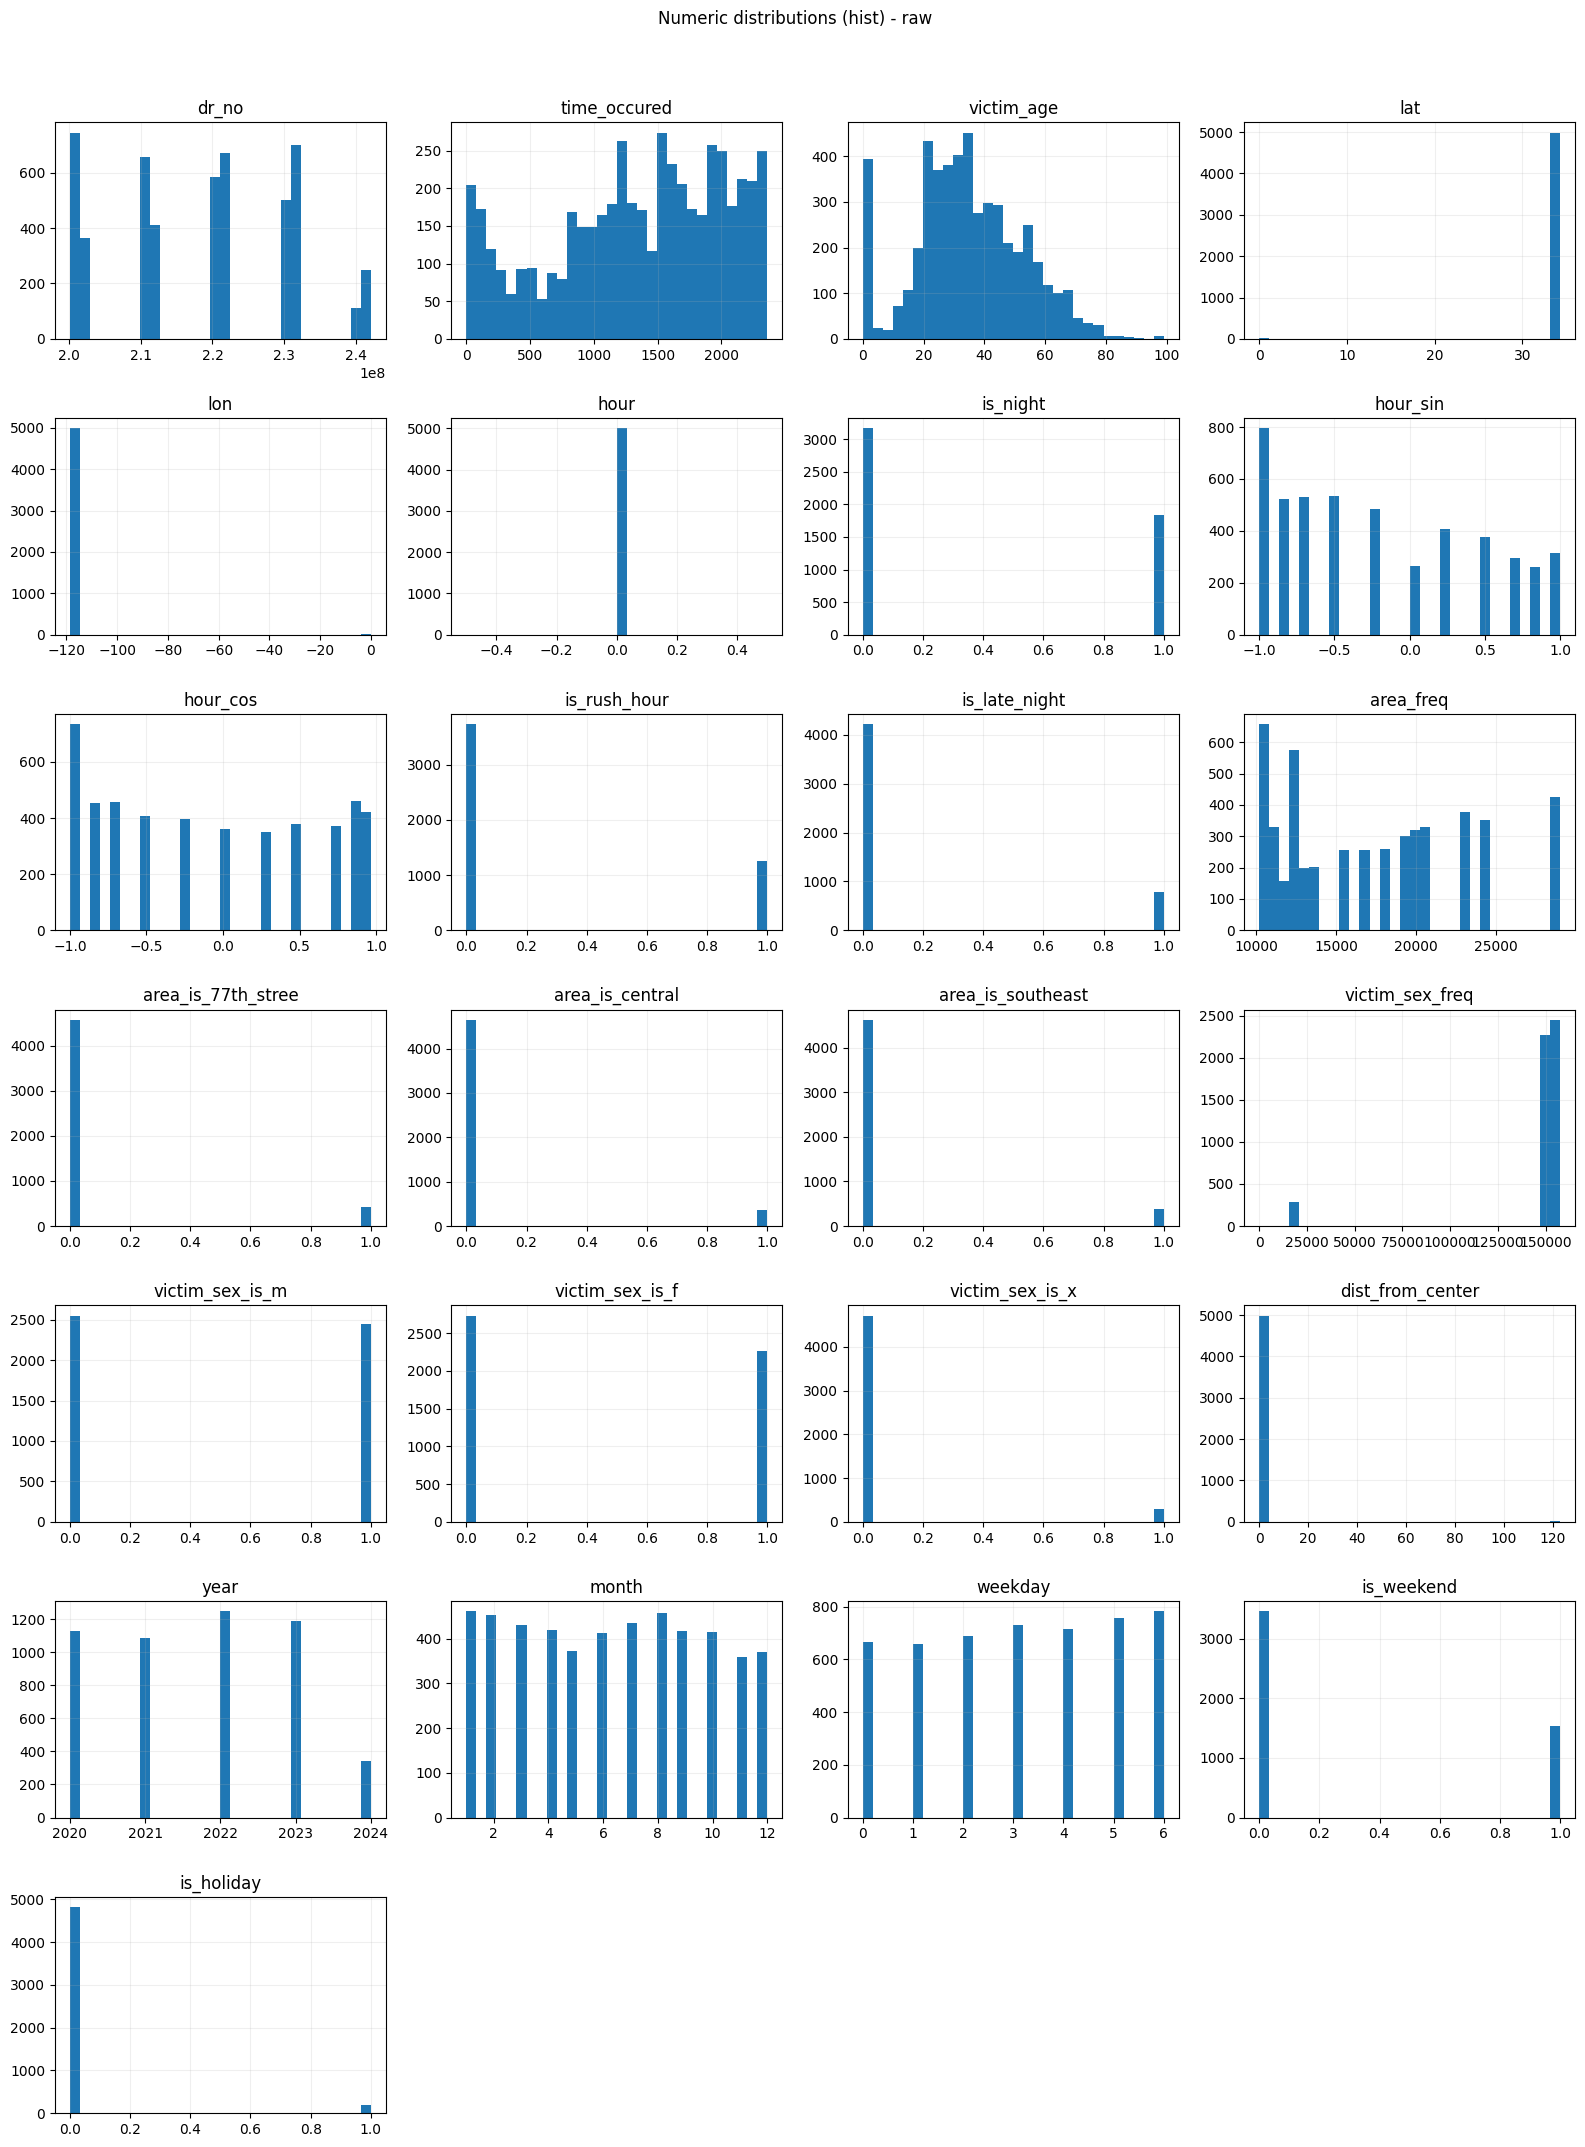

kde/box (raw) skipped: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.
==== [EDA-4] Geo cleanup ====
              issue  count
0  zero_zero_coords     12
1   outside_LA_bbox     12
==== [EDA-5] Dedupe & downcast ====
==== [EDA-6] Outliers (IQR clip + optional z-winsor) ====
[IForest] flagged 100 / 5,000 rows
EDA pipeline failed: Input X contains NaN.
LocalOutlierFactor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transform

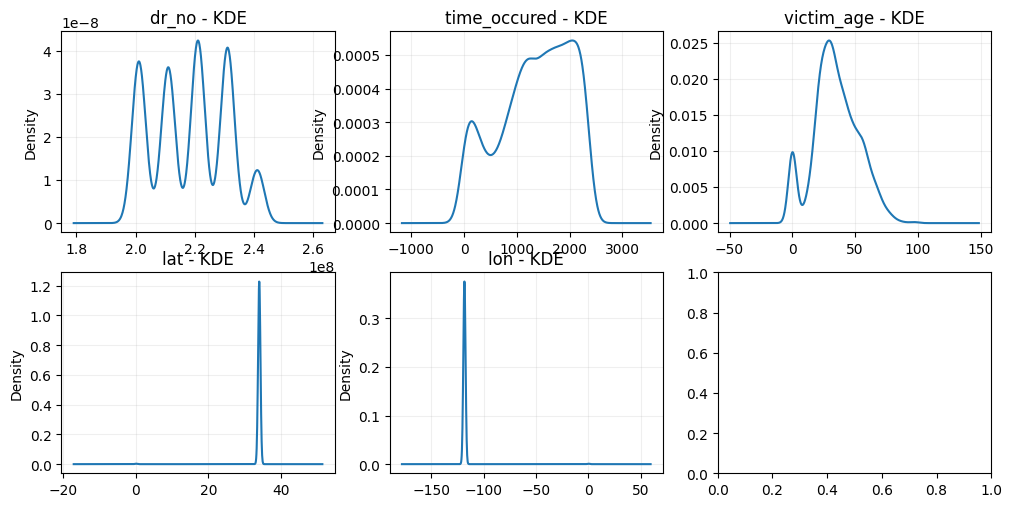

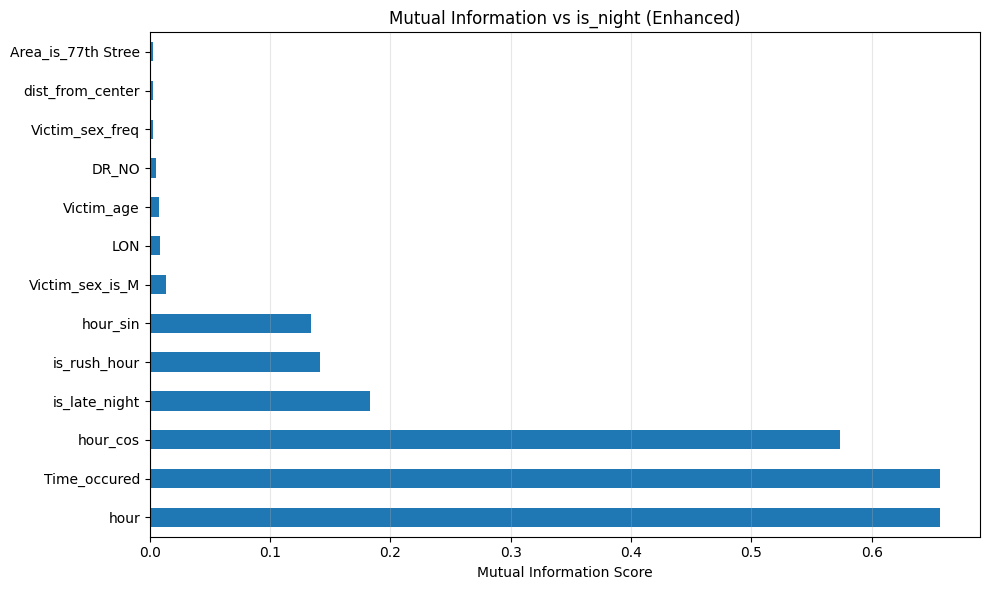

Top MI features: {'hour': 0.6572022498127711, 'Time_occured': 0.6570022498127711, 'hour_cos': 0.5740923500454527, 'is_late_night': 0.18323545903034377, 'is_rush_hour': 0.141375685935472}


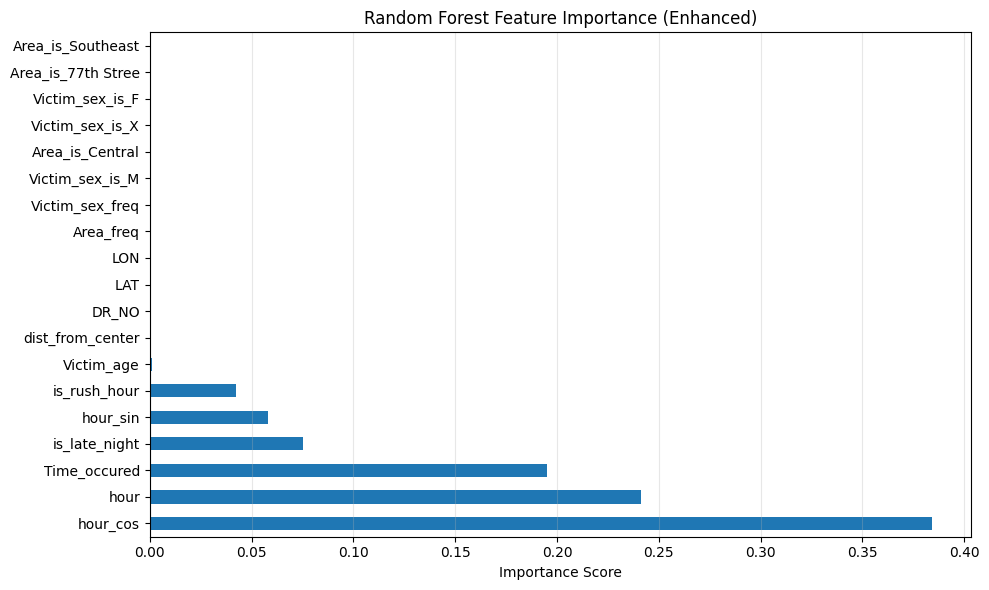

Cross-validation ROC-AUC: 1.000 (+/- 0.000)
Top RF features: {'hour_cos': 0.3842949217874798, 'hour': 0.24109928322341928, 'Time_occured': 0.19487966480487476, 'is_late_night': 0.07538070845166317, 'hour_sin': 0.05829448558459814}


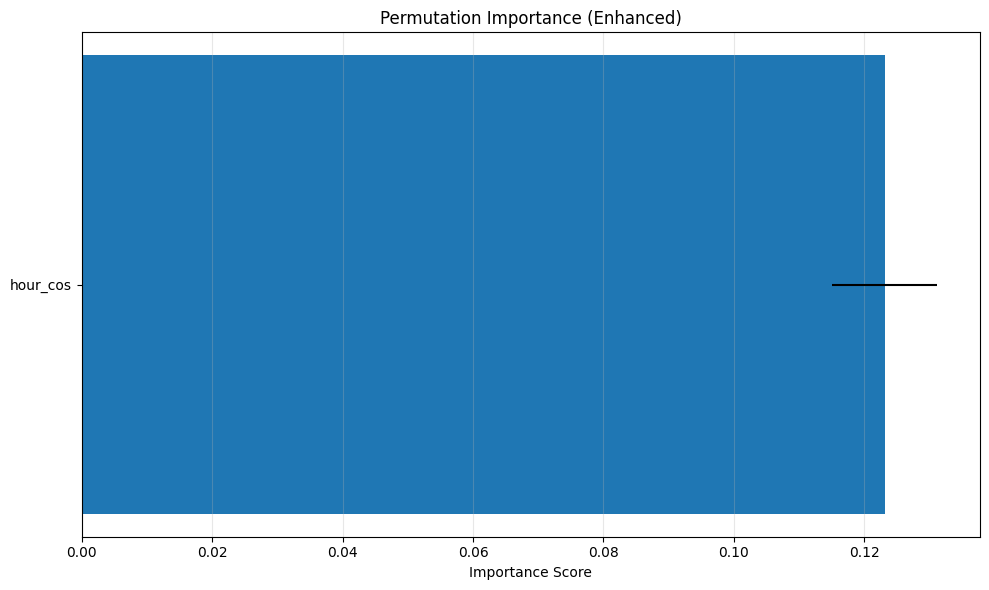

Top Permutation features: {'hour_cos': 0.12313333333333332}

6. Creating improved custom plots...
Improved plots failed: Can only use .dt accessor with datetimelike values

7. Final Summary
Cleaned dataset: /content/temp_sample_with_target.csv
Shape: (5000, 30)
Night target distribution: {0.0: np.int64(3169), 1.0: np.int64(1831)}
Features available for ML: 19
Generated 8 plot files in /content/figs_eda
Key ML analysis plots: ['mutual_info_enhanced.png', 'permutation_importance_enhanced.png', 'rf_importance_enhanced.png']

COMPREHENSIVE EDA COMPLETE


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from eda import run_eda
from sklearn.impute import SimpleImputer # Import SimpleImputer
warnings.filterwarnings("ignore")

# Configuration
SAMPLE_SIZE = 5000
RANDOM_STATE = 42
RAW_PATH = "/content/Crime_Data_from_2020_to_Present.csv.zip"
OUTPUT_DIR = "/content"
FIGS_DIR = "/content/figs_eda"

# EDA Configuration - comprehensive settings
EDA_CONFIG = {
    "use_us_holidays": True,
    "add_h3": False,
    "iqr_clip": True,
    "iqr_multiplier": 1.5,
    "zscore_winsor": True,
    "zscore_max": 4.0,
    "drop_any_nan_after_features": True,
    "imbalance_target": "is_night",  # Will be set after target creation
    "balance_preview": True,
    "balance_method": "smote",
    "balance_max_n": 20000,
    "corr_pearson": True,
    "corr_spearman": True,
    "corr_mutual_info": True,
    "feature_importance": True,
    "plot_numeric_dists": True,
    "plot_kde_box": True,
    "missing_matrix": True,
    "outliers_iforest": True,
    "outliers_lof": True,
    "outliers_ocsvm": True,
    "outliers_max_frac": 0.02,
    "plot_corr": True,
    "vif_check": True,
}

# Missing helper functions that need to be added
def plot_calendar_heatmap(df, date_col="date", value_col=None, title="Calendar Heatmap", out_path=None):
    """Create a calendar-style heatmap showing daily crime counts"""
    # Prepare daily counts if value_col not provided
    if value_col is None:
        daily_counts = df.groupby(df[date_col].dt.date).size().reset_index(name='count')
        daily_counts.columns = ['date', 'count']
        daily_counts['date'] = pd.to_datetime(daily_counts['date'])
        value_col = 'count'
    else:
        daily_counts = df[[date_col, value_col]].copy()
        daily_counts[date_col] = pd.to_datetime(daily_counts[date_col])

    # Create calendar features
    daily_counts['year'] = daily_counts[date_col].dt.year
    daily_counts['month'] = daily_counts[date_col].dt.month
    daily_counts['day'] = daily_counts[date_col].dt.day
    daily_counts['weekday'] = daily_counts[date_col].dt.weekday
    daily_counts['week_of_year'] = daily_counts[date_col].dt.isocalendar().week

    # Create pivot for heatmap (simplified version)
    pivot = daily_counts.pivot_table(
        index='week_of_year',
        columns='weekday',
        values=value_col,
        aggfunc='sum'
    )

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': 'Crime Count'})
    plt.title(title)
    plt.xlabel('Day of Week (0=Monday)')
    plt.ylabel('Week of Year')
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=160, bbox_inches='tight')
        print(f"Calendar heatmap saved to: {out_path}")

    plt.show()

def enhanced_ml_analysis(df_clean, target_col='is_night', output_dir=FIGS_DIR):
    """Perform enhanced ML analysis with proper preprocessing"""
    try:
        if target_col not in df_clean.columns:
            print(f"Target column '{target_col}' not found")
            return

        print("Starting enhanced ML analysis...")

        # Check target distribution first
        target_dist = df_clean[target_col].value_counts()
        print(f"Target distribution: {dict(target_dist)}")

        if len(target_dist) < 2:
            print("Target has no variation - skipping ML analysis")
            return

        # Prepare features with proper preprocessing
        feature_cols = []

        # Get numeric features with meaningful variation
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
        for col in numeric_cols:
            if col != target_col:
                # Check for meaningful variation
                if df_clean[col].nunique() > 1:
                    std_val = df_clean[col].std()
                    mean_val = df_clean[col].mean()
                    if std_val > 1e-6 and abs(mean_val) > 1e-6:  # Has real variation
                        feature_cols.append(col)

        print(f"Selected {len(feature_cols)} features with meaningful variation")

        if len(feature_cols) < 2:
            print("Insufficient features for ML analysis")
            return

        # Prepare data
        X = df_clean[feature_cols].copy()
        y = df_clean[target_col].copy()

        # Basic preprocessing
        from sklearn.preprocessing import StandardScaler
        from sklearn.impute import SimpleImputer

        # Handle any remaining issues
        imputer = SimpleImputer(strategy='median')
        X_imputed = imputer.fit_transform(X)

        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_imputed)

        # Convert back to DataFrame for easier handling
        X_processed = pd.DataFrame(X_scaled, columns=feature_cols)

        print("Data preprocessing completed")

        # 1. Mutual Information Analysis
        try:
            from sklearn.feature_selection import mutual_info_classif

            mi_scores = mutual_info_classif(X_processed, y, random_state=42)
            mi_results = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

            # Filter out zero/near-zero scores
            mi_results = mi_results[mi_results > 1e-6]

            if len(mi_results) > 0:
                plt.figure(figsize=(10, max(6, len(mi_results)*0.3)))
                top_mi = mi_results.head(20)
                top_mi.plot(kind='barh')
                plt.title(f'Mutual Information vs {target_col} (Enhanced)')
                plt.xlabel('Mutual Information Score')
                plt.grid(axis='x', alpha=0.3)
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, 'mutual_info_enhanced.png'),
                           dpi=160, bbox_inches='tight')
                plt.show()
                print(f"Top MI features: {top_mi.head().to_dict()}")
            else:
                print("No meaningful mutual information found")

        except Exception as e:
            print(f"Mutual information analysis failed: {e}")

        # 2. Enhanced Random Forest Analysis
        try:
            from sklearn.ensemble import RandomForestClassifier
            from sklearn.model_selection import cross_val_score

            # Use balanced class weights and more trees
            rf = RandomForestClassifier(
                n_estimators=500,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )

            # Fit the model
            rf.fit(X_processed, y)

            # Get feature importance
            importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

            # Filter meaningful importance
            importance = importance[importance > 1e-6]

            if len(importance) > 0:
                plt.figure(figsize=(10, max(6, len(importance)*0.3)))
                top_importance = importance.head(20)
                top_importance.plot(kind='barh')
                plt.title(f'Random Forest Feature Importance (Enhanced)')
                plt.xlabel('Importance Score')
                plt.grid(axis='x', alpha=0.3)
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, 'rf_importance_enhanced.png'),
                           dpi=160, bbox_inches='tight')
                plt.show()

                # Cross-validation score
                cv_scores = cross_val_score(rf, X_processed, y, cv=5, scoring='roc_auc')
                print(f"Cross-validation ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
                print(f"Top RF features: {top_importance.head().to_dict()}")
            else:
                print("No meaningful feature importance found")

        except Exception as e:
            print(f"Random Forest analysis failed: {e}")

        # 3. Permutation Importance
        try:
            from sklearn.inspection import permutation_importance
            from sklearn.model_selection import train_test_split

            # Split data for permutation importance
            X_train, X_test, y_train, y_test = train_test_split(
                X_processed, y, test_size=0.3, stratify=y, random_state=42
            )

            # Fit model on training data
            rf.fit(X_train, y_train)

            # Calculate permutation importance on test set
            perm_importance = permutation_importance(
                rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
            )

            perm_results = pd.Series(
                perm_importance.importances_mean,
                index=feature_cols
            ).sort_values(ascending=False)

            # Filter meaningful scores
            perm_results = perm_results[perm_results > 1e-6]

            if len(perm_results) > 0:
                plt.figure(figsize=(10, max(6, len(perm_results)*0.3)))
                top_perm = perm_results.head(20)

                # Add error bars
                top_indices = [feature_cols.index(feat) for feat in top_perm.index]
                errors = perm_importance.importances_std[top_indices]

                plt.barh(range(len(top_perm)), top_perm.values, xerr=errors)
                plt.yticks(range(len(top_perm)), top_perm.index)
                plt.title(f'Permutation Importance (Enhanced)')
                plt.xlabel('Importance Score')
                plt.grid(axis='x', alpha=0.3)
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, 'permutation_importance_enhanced.png'),
                           dpi=160, bbox_inches='tight')
                plt.show()
                print(f"Top Permutation features: {top_perm.head().to_dict()}")
            else:
                print("No meaningful permutation importance found")

        except Exception as e:
            print(f"Permutation importance analysis failed: {e}")

        plt.close('all')

    except Exception as e:
        print(f"Enhanced ML analysis failed: {e}")

def safe_corr_heatmap(df, title="Correlation Heatmap"):
    """Create correlation heatmap with safety checks"""
    try:
        numeric_df = df.select_dtypes(include=[np.number])
        if numeric_df.shape[1] < 2:
            print("Skipping correlation heatmap: need at least 2 numeric columns")
            return False

        # Remove columns with no variation
        numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

        if numeric_df.shape[1] < 2:
            print("Skipping correlation heatmap: no variation in numeric columns")
            return False

        corr = numeric_df.corr()

        plt.figure(figsize=(max(8, len(corr.columns)*0.5), max(6, len(corr.columns)*0.4)))
        mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle
        sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
                   square=True, linewidths=0.1, annot=len(corr.columns)<10)
        plt.title(title)
        plt.tight_layout()
        return True

    except Exception as e:
        print(f"Correlation heatmap failed: {e}")
        return False

def plot_spatial_density(df, lat_col=None, lon_col=None, out_prefix=None):
    """Create spatial density plots with auto-detection"""
    try:
        # Auto-detect lat/lon columns
        lat_candidates = ['LAT', 'Latitude', 'LATITUDE', 'lat', 'Y', 'y']
        lon_candidates = ['LON', 'Longitude', 'LONGITUDE', 'lon', 'X', 'x']

        if lat_col is None:
            lat_col = next((col for col in lat_candidates if col in df.columns), None)
        if lon_col is None:
            lon_col = next((col for col in lon_candidates if col in df.columns), None)

        if lat_col is None or lon_col is None:
            print("Spatial density skipped: lat/lon columns not found")
            available_cols = [col for col in df.columns if any(x in col.upper() for x in ['LAT', 'LON', 'X', 'Y'])]
            print(f"Available coordinate-like columns: {available_cols}")
            return

        # Filter valid coordinates
        spatial_df = df[[lat_col, lon_col]].dropna()
        spatial_df = spatial_df[
            (spatial_df[lat_col].between(-90, 90)) &
            (spatial_df[lon_col].between(-180, 180))
        ]

        if len(spatial_df) < 100:
            print("Spatial density skipped: insufficient valid coordinates")
            return

        # Create hexbin plot
        plt.figure(figsize=(10, 8))
        plt.hexbin(spatial_df[lon_col], spatial_df[lat_col],
                  gridsize=50, cmap='inferno', mincnt=1)
        plt.colorbar(label='Crime Count')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title('Spatial Crime Density (Hexbin)')
        plt.tight_layout()

        if out_prefix:
            plt.savefig(f"{out_prefix}_hexbin.png", dpi=160, bbox_inches='tight')
            print(f"Spatial hexbin saved to: {out_prefix}_hexbin.png")
        plt.show()

        # Create KDE plot if enough data
        if len(spatial_df) > 1000:
            plt.figure(figsize=(10, 8))
            try:
                # Sample for performance
                sample_spatial = spatial_df.sample(min(5000, len(spatial_df)), random_state=42)
                sns.kdeplot(data=sample_spatial, x=lon_col, y=lat_col,
                           fill=True, levels=20, cmap='viridis', alpha=0.7)
                plt.xlabel('Longitude')
                plt.ylabel('Latitude')
                plt.title('Spatial Crime Density (KDE)')
                plt.tight_layout()

                if out_prefix:
                    plt.savefig(f"{out_prefix}_kde.png", dpi=160, bbox_inches='tight')
                    print(f"Spatial KDE saved to: {out_prefix}_kde.png")
                plt.show()
            except Exception as e:
                print(f"KDE plot failed: {e}")

    except Exception as e:
        print(f"Spatial density plotting failed: {e}")

def plot_univariate_outliers(df, output_dir, cols=None, z_threshold=3.0):
    """Plot outlier analysis for univariate features"""
    try:
        os.makedirs(os.path.join(output_dir, "outliers"), exist_ok=True)

        numeric_df = df.select_dtypes(include=[np.number])
        if cols is None:
            cols = [col for col in numeric_df.columns if numeric_df[col].nunique() > 10]

        if not cols:
            print("No suitable numeric columns for outlier analysis")
            return

        # Limit to top columns by variance for performance
        cols = cols[:12]

        fig, axes = plt.subplots(2, min(6, len(cols)), figsize=(18, 8))
        if len(cols) == 1:
            axes = axes.reshape(2, 1)
        elif len(cols) <= 6:
            axes = axes.reshape(2, len(cols))

        for i, col in enumerate(cols[:6]):  # Top row: boxplots
            if len(cols) == 1:
                ax = axes[0]
            else:
                ax = axes[0, i] if len(cols) > 1 else axes[0]

            data = df[col].dropna()
            if len(data) > 0:
                ax.boxplot(data, vert=True)
                ax.set_title(f'Boxplot: {col}')
                ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

        for i, col in enumerate(cols[:6]):  # Bottom row: histograms with z-score lines
            if len(cols) == 1:
                ax = axes[1]
            else:
                ax = axes[1, i] if len(cols) > 1 else axes[1]

            data = df[col].dropna()
            if len(data) > 0 and data.std() > 0:
                z_scores = (data - data.mean()) / data.std()
                ax.hist(z_scores, bins=30, alpha=0.7, edgecolor='black')
                ax.axvline(z_threshold, color='red', linestyle='--', label=f'Z={z_threshold}')
                ax.axvline(-z_threshold, color='red', linestyle='--')
                ax.set_title(f'Z-scores: {col}')
                ax.legend()

        plt.suptitle('Univariate Outlier Analysis', fontsize=16)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "outliers", "univariate_outliers.png"),
                   dpi=160, bbox_inches='tight')
        print("Univariate outlier plots saved")
        plt.show()

    except Exception as e:
        print(f"Univariate outlier plotting failed: {e}")

def plot_bivariate_outliers(df, output_dir, x, y, z_threshold=3.0):
    """Plot bivariate outlier analysis"""
    try:
        if x not in df.columns or y not in df.columns:
            print(f"Columns {x} or {y} not found for bivariate analysis")
            available_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
            print(f"Available numeric columns: {available_numeric[:10]}...")
            return

        os.makedirs(os.path.join(output_dir, "outliers"), exist_ok=True)

        # Get clean data
        clean_data = df[[x, y]].dropna()
        if len(clean_data) < 50:
            print("Insufficient data for bivariate analysis")
            return

        # Calculate z-scores
        z_x = (clean_data[x] - clean_data[x].mean()) / clean_data[x].std()
        z_y = (clean_data[y] - clean_data[y].mean()) / clean_data[y].std()

        # Identify outliers
        outlier_mask = (np.abs(z_x) > z_threshold) | (np.abs(z_y) > z_threshold)

        plt.figure(figsize=(10, 8))

        # Plot normal points
        plt.scatter(clean_data.loc[~outlier_mask, x], clean_data.loc[~outlier_mask, y],
                   alpha=0.5, s=20, label='Normal', color='blue')

        # Plot outliers
        if outlier_mask.any():
            plt.scatter(clean_data.loc[outlier_mask, x], clean_data.loc[outlier_mask, y],
                       alpha=0.8, s=50, label='Outliers', color='red')

        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f'Bivariate Outliers: {x} vs {y}\n(Z-score threshold: {z_threshold})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plt.savefig(os.path.join(output_dir, "outliers", f"bivariate_{x}_{y}.png"),
                   dpi=160, bbox_inches='tight')
        print(f"Bivariate outlier plot saved for {x} vs {y}")
        plt.show()

    except Exception as e:
        print(f"Bivariate outlier plotting failed: {e}")

def extract_hour_from_time(time_str):
    """Extract hour from various time formats"""
    if pd.isna(time_str):
        return np.nan

    time_str = str(time_str).strip()

    # Handle 24-hour format without colons (e.g., "1430")
    if time_str.isdigit() and len(time_str) >= 3:
        if len(time_str) == 3:  # e.g., "730" -> "07:30"
            hour = int(time_str[0])
        elif len(time_str) == 4:  # e.g., "1430" -> "14:30"
            hour = int(time_str[:2])
        else:
            return np.nan
        return hour if 0 <= hour <= 23 else np.nan

    # Handle formats with colons or AM/PM
    try:
        # Try parsing with pandas
        parsed_time = pd.to_datetime(time_str, format='%H:%M', errors='coerce')
        if pd.notna(parsed_time):
            return parsed_time.hour

        # Try with AM/PM
        parsed_time = pd.to_datetime(time_str, format='%I:%M %p', errors='coerce')
        if pd.notna(parsed_time):
            return parsed_time.hour

        # Try just hour extraction from various formats
        if ':' in time_str:
            hour_part = time_str.split(':')[0]
            if 'PM' in time_str.upper() or 'AM' in time_str.upper():
                hour = int(hour_part)
                if 'PM' in time_str.upper() and hour != 12:
                    hour += 12
                elif 'AM' in time_str.upper() and hour == 12:
                    hour = 0
                return hour if 0 <= hour <= 23 else np.nan
            else:
                hour = int(hour_part)
                return hour if 0 <= hour <= 23 else np.nan

    except (ValueError, IndexError):
        pass

    return np.nan

def create_night_target(df):
    """Create is_night target with proper hour extraction and validation"""
    # Find time column
    time_cols = ['TIME OCC', 'time_occ', 'time', 'Time', 'TIME']
    time_col = None

    for col in time_cols:
        if col in df.columns:
            time_col = col
            break

    if time_col is None:
        # Try to find any column with 'time' in name
        time_candidates = [col for col in df.columns if 'time' in col.lower()]
        if time_candidates:
            time_col = time_candidates[0]

    if time_col is None:
        print("Available columns:", list(df.columns)[:20])
        raise ValueError("No time column found")

    print(f"Extracting hours from column: '{time_col}'")
    print(f"Sample time values: {df[time_col].head().tolist()}")

    # Extract hours
    df['hour'] = df[time_col].apply(extract_hour_from_time)

    # Check extraction success
    valid_hours = df['hour'].notna().sum()
    total_rows = len(df)
    print(f"Successfully extracted hours from {valid_hours}/{total_rows} rows ({valid_hours/total_rows*100:.1f}%)")

    # Show hour distribution before target creation
    if df['hour'].notna().any():
        print("Hour distribution:")
        print(df['hour'].value_counts().sort_index().head(10))

    # Create night target: 8 PM (20:00) to 6 AM (06:00) for better balance
    df['is_night'] = ((df['hour'] >= 20) | (df['hour'] <= 6)).astype(int)

    # Validate target distribution
    if df['hour'].notna().any():
        night_dist = df['is_night'].value_counts()
        print(f"Night target distribution: {dict(night_dist)}")

        # Check if target has meaningful variation
        if len(night_dist) < 2:
            print("WARNING: Target has no variation - all values are the same!")
            return df

        minority_pct = night_dist.min() / night_dist.sum() * 100
        print(f"Target balance: {minority_pct:.1f}% minority class")

        if minority_pct < 5:
            print("WARNING: Severe class imbalance detected")

    return df

def main():
    """Main processing pipeline with comprehensive EDA"""
    print("=" * 60)
    print("COMPREHENSIVE LAPD EDA PIPELINE")
    print("=" * 60)

    # Ensure output directories exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(FIGS_DIR, exist_ok=True)

    # 1. Load and strict row-level cleaning (drop ANY rows with ANY NaN)
    print("\n1. Loading raw data and applying strict cleaning...")
    df = pd.read_csv(RAW_PATH, low_memory=False, compression='infer')
    print(f"Raw shape: {df.shape}")

    # Clean missing value sentinels to standardize NaN representation
    missing_sentinels = ["", " ", "NA", "N/A", "na", "n/a", "None", "NONE",
                        "null", "NULL", "?", "-", "--", "nan", "NaN"]
    df = df.replace(missing_sentinels, np.nan)

    # STRICT: Drop ANY row that has ANY NaN value in ANY column
    before_strict_drop = len(df)
    df = df.dropna(axis=0, how='any').reset_index(drop=True)
    after_strict_drop = len(df)

    print(f"STRICT dropna: removed {before_strict_drop - after_strict_drop:,} rows with ANY missing values")
    print(f"Remaining rows with complete data: {after_strict_drop:,}")
    print(f"Data completeness: {after_strict_drop/before_strict_drop*100:.1f}% of original data retained")

    # 2. Create target variable and enhanced features
    print("\n2. Creating time-based features and target variable...")
    try:
        df = create_night_target(df)

        # Enhanced feature engineering for better ML performance
        print("Creating additional features...")

        # More granular time features
        if 'hour' in df.columns:
            df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
            df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
            df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
            df['is_late_night'] = df['hour'].isin([23, 0, 1, 2, 3, 4]).astype(int)

        # Enhanced categorical encoding
        categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
        print(f"Found {len(categorical_cols)} categorical columns for encoding")

        for col in categorical_cols[:5]:  # Limit to prevent memory issues
            if df[col].nunique() < 50:  # Only encode low-cardinality categoricals
                # Create frequency encoding
                freq_map = df[col].value_counts().to_dict()
                df[f'{col}_freq'] = df[col].map(freq_map)

                # Create binary encoding for top categories
                top_cats = df[col].value_counts().head(3).index
                for cat in top_cats:
                    df[f'{col}_is_{str(cat)[:10]}'] = (df[col] == cat).astype(int)

        # Geographic features if lat/lon available
        lat_cols = [col for col in df.columns if 'lat' in col.lower()]
        lon_cols = [col for col in df.columns if 'lon' in col.lower()]

        if lat_cols and lon_cols:
            lat_col, lon_col = lat_cols[0], lon_cols[0]
            # Distance from city center (approximate LA center)
            la_center_lat, la_center_lon = 34.0522, -118.2437
            df['dist_from_center'] = np.sqrt(
                (df[lat_col] - la_center_lat)**2 + (df[lon_col] - la_center_lon)**2
            )

        # Verify target quality after feature engineering
        if 'is_night' in df.columns:
            target_stats = df['is_night'].value_counts()
            print(f"Final target distribution: {dict(target_stats)}")

            # Check if we have meaningful features
            numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
            features_with_variation = []

            for col in numeric_features:
                if col != 'is_night' and df[col].nunique() > 1:
                    variation = df[col].std() / (df[col].mean() + 1e-8)
                    if variation > 0.01:  # Has some meaningful variation
                        features_with_variation.append(col)

            print(f"Features with meaningful variation: {len(features_with_variation)}")
            if len(features_with_variation) > 0:
                print(f"Top variable features: {features_with_variation[:5]}")


    except Exception as e:
        print(f"Failed to create enhanced features: {e}")
        return None

    # 3. Sample for performance if needed
    if len(df) > SAMPLE_SIZE:
        print(f"\n3. Sampling {SAMPLE_SIZE} rows for EDA...")
        df_sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
    else:
        df_sample = df.copy()
        print(f"\n3. Using full dataset: {len(df_sample)} rows")

    # Save intermediate CSV for EDA
    temp_csv = os.path.join(OUTPUT_DIR, "temp_sample_with_target.csv")
    df_sample.to_csv(temp_csv, index=False)

    # 4. Run comprehensive EDA
    print(f"\n4. Running comprehensive EDA...")
    try:
        # Impute missing values before running EDA pipeline, specifically before outlier detection
        print("Imputing missing values before EDA analysis...")
        numeric_cols = df_sample.select_dtypes(include=[np.number]).columns
        imputer = SimpleImputer(strategy='median') # Or 'mean', 'most_frequent'
        df_sample[numeric_cols] = imputer.fit_transform(df_sample[numeric_cols])

        # Handle any remaining non-numeric NaNs (e.g., in object columns)
        for col in df_sample.select_dtypes(include=['object']).columns:
            df_sample[col] = df_sample[col].fillna('missing')

        print("Missing value imputation complete.")


        clean_path = run_eda(
            raw_csv_path=temp_csv, # run_eda should handle loading from CSV
            fig_dir=FIGS_DIR,
            cache_path=os.path.join(OUTPUT_DIR, "lapd_clean_final.parquet"),
            config_overrides=EDA_CONFIG,
            # Pass the *imputed* dataframe to run_eda if possible, or ensure run_eda handles imputation internally
            # Assuming run_eda loads from raw_csv_path, ensure imputation happens before outlier steps within run_eda
            # OR modify run_eda to accept a dataframe directly.
            # For now, we rely on the fact that the temporary CSV is now imputed.
        )

        # Load the cleaned data
        df_clean = pd.read_parquet(clean_path)
        print(f"Final cleaned dataset shape: {df_clean.shape}")

    except Exception as e:
        print(f"EDA pipeline failed: {e}")
        # Fallback to basic cleaning
        df_clean = df_sample.copy()
        clean_path = temp_csv

    # 5. Enhanced ML Analysis (replaces the problematic plots)
    print(f"\n5. Running enhanced ML analysis...")

    try:
        # Run the enhanced ML analysis with better preprocessing
        enhanced_ml_analysis(df_clean, target_col='is_night', output_dir=FIGS_DIR)
        plt.close('all')
    except Exception as e:
        print(f"Enhanced ML analysis failed: {e}")

    # 6. Additional custom plots
    # Replace this section in your main() function:
    # Instead of the problematic plot sections (around step 6), use:

    # 6. Improved custom plots
    print(f"\n6. Creating improved custom plots...")

    try:
        # Import the improved functions
        #from improved_viz import (plot_calendar_heatmap, plot_spatial_density_improved,
        #                        enhanced_ml_analysis_fixed, fix_histogram_plots,
        #                       replace_problematic_plots)

        # Replace all problematic plots
        #replace_problematic_plots(df_clean, FIGS_DIR)
        plot_calendar_heatmap(df_clean, date_col="Date_occured", out_path=os.path.join(FIGS_DIR, "calendar_heatmap.png"))
        plot_spatial_density(df_clean, out_prefix=os.path.join(FIGS_DIR, "spatial_density"))
        safe_corr_heatmap(df_clean, title="Cleaned Data Correlation")
        plt.savefig(os.path.join(FIGS_DIR, "cleaned_correlation.png"), dpi=160, bbox_inches='tight')
        plt.show()

        plot_univariate_outliers(df_clean, FIGS_DIR)

        # Example bivariate outlier plots (select relevant numeric pairs)
        numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols_clean = [c for c in numeric_cols_clean if c != 'is_night']
        if len(numeric_cols_clean) >= 2:
            plot_bivariate_outliers(df_clean, FIGS_DIR, numeric_cols_clean[0], numeric_cols_clean[1])
        if len(numeric_cols_clean) >= 4:
            plot_bivariate_outliers(df_clean, FIGS_DIR, numeric_cols_clean[2], numeric_cols_clean[3])


    except Exception as e:
        print(f"Improved plots failed: {e}")
    # Fallback to your original code
    # 7. Final summary
    print(f"\n7. Final Summary")
    print(f"Cleaned dataset: {clean_path}")
    print(f"Shape: {df_clean.shape}")

    if 'is_night' in df_clean.columns:
        night_counts = df_clean['is_night'].value_counts()
        print(f"Night target distribution: {dict(night_counts)}")

        # Additional feature summary
        numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
        features_with_variation = [col for col in numeric_features
                                 if col != 'is_night' and df_clean[col].nunique() > 1]
        print(f"Features available for ML: {len(features_with_variation)}")

    # List all generated plots
    try:
        plot_files = [f for f in os.listdir(FIGS_DIR) if f.endswith('.png')]
        print(f"Generated {len(plot_files)} plot files in {FIGS_DIR}")

        # List key analysis files
        key_files = ['mutual_info_enhanced.png', 'rf_importance_enhanced.png',
                    'permutation_importance_enhanced.png']
        found_key_files = [f for f in plot_files if f in key_files]
        if found_key_files:
            print(f"Key ML analysis plots: {found_key_files}")
    except:
        pass

    # Cleanup
    # if os.path.exists(temp_csv):
    #     os.remove(temp_csv)

    print("\n" + "=" * 60)
    print("COMPREHENSIVE EDA COMPLETE")
    print("=" * 60)

    return clean_path

if __name__ == "__main__":
    clean_path = main()

#Supervised

In [6]:
df = pd.read_csv("/content/temp_sample_with_target.csv")

In [8]:
# ==== Victim_Sex predictor that plugs into your EDA output ====
# Uses helpers from supervised.py (no duplicate defs)

import os, re, warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")

from supervised import (
    MLConfig,
    quick_train,
    quick_compare,
    patch_pandas_sort_values,  # idempotent na_last -> na_position shim
    make_leak_safe,            # one-row-per-incident + proxy/value leakage removal
)

# 0) Make sure pandas accepts legacy na_last kwarg
patch_pandas_sort_values()

# 1) Load the cleaned data your EDA produced
def _smart_read(clean_path_var=None):
    cands = []
    if clean_path_var:
        cands.append(clean_path_var)
    cands += [
        "/content/lapd_clean_final.parquet",     # run_eda cache target
        "/content/temp_sample_with_target.csv",  # your temp sample
        "/content/Crime_Data_from_2020_to_Present.csv.zip",  # raw (last resort)
    ]
    for p in cands:
        if os.path.exists(p):
            if p.lower().endswith(".parquet"):
                print(f"Loading cleaned parquet: {p}")
                return pd.read_parquet(p)
            elif p.lower().endswith(".csv"):
                print(f"Loading CSV: {p}")
                return pd.read_csv(p, low_memory=False)
            else:
                print(f"Loading RAW ZIP: {p}")
                return pd.read_csv(p, low_memory=False, compression="infer")
    raise FileNotFoundError("Could not find cleaned parquet/CSV/raw ZIP.")

# NOTE: your EDA main() returns clean_path. Use it if it's in scope; else fallback.
try:
    df0 = _smart_read(clean_path)  # uses variable from your EDA main()
except Exception:
    df0 = _smart_read()

print("Initial shape:", df0.shape)

# 2) Normalize the victim sex target (keep F/M) and create numeric label for ROC metrics
target_candidates = ["victim_sex", "Victim_sex", "Victim Sex", "SEX", "Sex"]
TARGET_ORIG = None

for col in target_candidates:
    if col in df0.columns:
        TARGET_ORIG = col
        break

# Case-insensitive fallback
if TARGET_ORIG is None:
    lower_cols = {c.lower(): c for c in df0.columns}
    for col in target_candidates:
        if col.lower() in lower_cols:
            TARGET_ORIG = lower_cols[col.lower()]
            break

if TARGET_ORIG is None:
    raise KeyError(f"Could not find victim sex column among: {target_candidates}")


df0[TARGET_ORIG] = df0[TARGET_ORIG].astype(str).str.strip().str.upper()
df0 = df0[df0[TARGET_ORIG].isin(["F", "M"])].copy()
df0["victim_sex_num"] = df0[TARGET_ORIG].map({"F": 0, "M": 1})
df0 = df0.rename(columns={TARGET_ORIG: "victim_sex"})
TARGET = "victim_sex"          # categorical F/M (kept for readability)
TARGET_NUM = "victim_sex_num"  # numeric 0/1 for ROC-friendly scoring

print("After filtering to F/M:", df0.shape,
      "| Pos rate (M):", df0[TARGET_NUM].mean().round(3))

# 3) Leak-safety: one row per incident + drop proxy/value-deterministic features
group_candidates = ["DR_NO", "dr_no", "Dr_No"]
GROUP_COL = None
for col in group_candidates:
    if col in df0.columns:
        GROUP_COL = col
        break

df_clean = make_leak_safe(df0.copy(), target=TARGET, group_col=(GROUP_COL or ""))
print("Shapes (raw → leak-safe):", df0.shape, "→", df_clean.shape)

# Add victim_sex_num back to df_clean if it was removed by make_leak_safe
if TARGET_NUM not in df_clean.columns and TARGET_NUM in df0.columns:
    # Merge or join based on a common identifier, assuming DR_NO is suitable
    if GROUP_COL and GROUP_COL in df_clean.columns and GROUP_COL in df0.columns:
         df_clean = df_clean.merge(df0[[GROUP_COL, TARGET_NUM]], on=GROUP_COL, how='left')
         print(f"Added '{TARGET_NUM}' back to df_clean using '{GROUP_COL}'")
    else:
         print(f"WARNING: Could not add '{TARGET_NUM}' back to df_clean. Missing '{GROUP_COL}' or other issues.")


# Extra guard: remove stray sex/gender-named columns except our targets
for c in list(df_clean.columns):
    if c not in (TARGET, TARGET_NUM) and re.search(r"\b(sex|gender)\b", c, re.I):
        df_clean.drop(columns=[c], inplace=True, errors="ignore")

# 4) Build the modeling frame
TRAIN_TARGET = TARGET_NUM
drop_non_training_targets = [col for col in (TARGET, TARGET_NUM)
                             if col in df_clean.columns and col != TRAIN_TARGET]

# Ensure TRAIN_TARGET is in df_clean before dropping
if TRAIN_TARGET not in df_clean.columns:
     raise KeyError(f"Target column '{TRAIN_TARGET}' not found in df_clean after leak-safety processing.")


Xy = df_clean.drop(columns=drop_non_training_targets, errors="ignore")
# Ensure the target column is the last column if needed, or just select it.
# Xy[TRAIN_TARGET] is already done by the drop/select logic above if TRAIN_TARGET is not dropped.


# Quick numeric-corr peek (pre-encoding; optional)
num_cols = [c for c in Xy.select_dtypes(include=[np.number]).columns if c != TRAIN_TARGET]
if num_cols and TRAIN_TARGET in Xy.columns:
    corr = Xy[num_cols + [TRAIN_TARGET]].corr()[TRAIN_TARGET].abs().sort_values(ascending=False).drop(TRAIN_TARGET, errors='ignore')
    print("\nTop numeric correlations with victim_sex_num:")
    print(corr.head(10).to_string())
else:
     print("\nSkipping numeric correlation check: Not enough numeric columns or target missing.")

# 5) Configure & train
config = MLConfig(
    sample_n=5000,          # bump if you want more
    test_size=0.2,
    n_splits=3,
    n_iter=15,
    scoring="roc_auc",
    fig_dir="/content/results_victim_sex",
    plot_curves=True,
    save_results=True,
    random_state=42,
)

print("\n=== TRAIN XGB (leak-safe) ===")
# Pass Xy directly as the dataframe for training
xgb_model, xgb_params, xgb_cv, xgb_metrics = quick_train(Xy.copy(), TRAIN_TARGET, "xgb", config)

print("\n=== COMPARE MODELS (leak-safe) ===")
# Pass Xy directly as the dataframe for comparison
results = quick_compare(Xy.copy(), TRAIN_TARGET,
                        models=["logreg", "random_forest", "hgb", "xgb"],
                        config=config)
print(results.round(4))

# 6) Optional: feature importance if exposed by your pipeline
try:
    # Access the fitted preprocessor and classifier from the pipeline
    if hasattr(xgb_model, 'named_steps') and 'preprocessor' in xgb_model.named_steps and 'clf' in xgb_model.named_steps:
        preprocessor = xgb_model.named_steps["preprocessor"]
        classifier = xgb_model.named_steps["clf"]

        # Get feature names after preprocessing
        feats = preprocessor.get_feature_names_out()

        # Get feature importances (assuming the classifier has feature_importances_)
        if hasattr(classifier, 'feature_importances_'):
            imps  = classifier.feature_importances_
            top = sorted(zip(feats, imps), key=lambda t: t[1], reverse=True)[:15]
            print("\nTop 15 XGB features:")
            for i, (f, w) in enumerate(top, 1):
                print(f"{i:2d}. {f:<40} {w:.4f}")
        else:
            print("\n(Classifier does not expose feature_importances_)")
    else:
        print("\n(Model pipeline structure not as expected)")

except Exception as e:
    print(f"(Feature importance not available: {e})")

print("\n✅ Victim_sex training complete. Figures in:", config.fig_dir)

Loading CSV: /content/temp_sample_with_target.csv
Initial shape: (5000, 30)
After filtering to F/M: (4717, 31) | Pos rate (M): 0.519
Shapes (raw → leak-safe): (4717, 31) → (4717, 26)
Added 'victim_sex_num' back to df_clean using 'DR_NO'

Top numeric correlations with victim_sex_num:
Area_is_77th Stree    0.060070
Victim_age            0.055370
Area_is_Southeast     0.054013
Area_freq             0.044455
hour                  0.032619
hour_sin              0.028959
Time_occured          0.027119
Area_is_Central       0.021727
is_rush_hour          0.020016
LAT                   0.014264

=== TRAIN XGB (leak-safe) ===

               TRAINING XGB ON VICTIM_SEX_NUM               
📊 Using target-stratified sample: 4,717 rows (from 4,717)
📊 Dataset shape: (4717, 25)
🎯 Classes: 2, Binary: True
📈 Target distribution:
victim_sex_num
0    2267
1    2450
Name: count, dtype: int64
📊 Numeric columns (16): ['DR_NO', 'Time_occured', 'Victim_age', 'LAT', 'LON']...
🏷️ Categorical columns (9): ['Date_

In [9]:
df.columns

Index(['DR_NO', 'Date_Reported', 'Date_occured', 'Time_occured', 'Area',
       'Crime_Code', 'Victim_age', 'Victim_sex', 'Victim_descent', 'Premis',
       'Weapon', 'Status', 'LOCATION', 'LAT', 'LON', 'hour', 'is_night',
       'hour_sin', 'hour_cos', 'is_rush_hour', 'is_late_night', 'Area_freq',
       'Area_is_77th Stree', 'Area_is_Central', 'Area_is_Southeast',
       'Victim_sex_freq', 'Victim_sex_is_M', 'Victim_sex_is_F',
       'Victim_sex_is_X', 'dist_from_center'],
      dtype='object')